In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

import optuna
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_validate
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from config.paths import config

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
processed_data = joblib.load(config.processed_data_dir / "feature_engineered_data.pkl")
X_train = processed_data['X_train']
X_test = processed_data['X_test']
y_train = processed_data['y_train']
y_test = processed_data['y_test']

feature_names = processed_data['feature_names']
with open(config.reports_dir / 'fast_baseline_models_results.json', 'r') as f:
    baseline_results = json.load(f)
print(f"Training data: {X_train.shape}")
print(f"Testing data: {X_test.shape}")

Training data: (156156, 82)
Testing data: (39040, 82)


In [3]:
performance_data = []
for model_data in baseline_results['performance_summary']:
    accuracy_str = model_data['Accuracy'].split(' ± ')[0]
    roc_auc_str = model_data['ROC-AUC'].split(' ± ')[0]
    training_time_str = model_data['Training Time (s)']
    performance_data.append({
        'model': model_data['Model'],
        'accuracy': float(accuracy_str),
        'roc_auc': float(roc_auc_str),
        'training_time': float(training_time_str)
    })
performance_df = pd.DataFrame(performance_data)
performance_df['overall_score'] = (performance_df['accuracy'] * 0.4 +
                                  performance_df['roc_auc'] * 0.4 +
                                  (1 / performance_df['training_time']) * 0.2)

all_models = performance_df['model'].tolist()

print("ALL MODELS AVAILABLE FOR TUNING:")
for i, (idx, row) in enumerate(performance_df.iterrows()):
    print(f"{i+1}. {row['model']}: Accuracy: {row['accuracy']:.4f}, ROC-AUC: {row['roc_auc']:.4f}")

ALL MODELS AVAILABLE FOR TUNING:
1. Logistic Regression: Accuracy: 0.9741, ROC-AUC: 0.9960
2. Random Forest: Accuracy: 0.9759, ROC-AUC: 0.9962
3. XGBoost: Accuracy: 0.9832, ROC-AUC: 0.9986
4. LightGBM: Accuracy: 0.9832, ROC-AUC: 0.9986
5. Linear SVM: Accuracy: 0.9729, ROC-AUC: 0.9961
6. KNN: Accuracy: 0.9339, ROC-AUC: 0.9652


In [4]:
xgb_param_space = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 6, 9],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0, 0.1, 1],
    'min_child_weight': [1, 3, 5]
}

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

lgb_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [31, 63, 127, 255],
    'max_depth': [-1, 10, 20, 30],
    'min_child_samples': [20, 50, 100],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0, 0.1, 0.5, 1]
}

lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000, 2000]
}

svm_param_dist = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'degree': [2, 3, 4],
    'probability': [True]
}

knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

In [5]:
def objective_xgb(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'logloss',
        'use_label_encoder': False
    }

    model = XGBClassifier(**params)
    cv_scores = cross_validate(model, X_train, y_train, cv=2, scoring='roc_auc', n_jobs=-1)
    return np.mean(cv_scores['test_score'])

In [6]:
optimized_models = {}
optimization_results = {}
tuning_results = {}

cv_fast = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("=" * 50)
print("HYPERPARAMETER OPTIMIZATION STARTED")
print("=" * 50)

print("SKIPPING SVM AND KNN - TOO SLOW FOR LARGE DATASET")
models_to_use = [model for model in all_models if model not in ['Linear SVM', 'KNN']]
print(f"Optimizing models: {models_to_use}")
print()

optuna.logging.set_verbosity(optuna.logging.WARNING)

if 'XGBoost' in models_to_use:
    print("XGBoost - Bayesian Optimization (10 trials)")
    print("-" * 40)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective_xgb, n_trials=10, show_progress_bar=False)

    best_xgb_params = study.best_params
    optimized_models['XGBoost'] = XGBClassifier(**best_xgb_params)
    xgb_scores = cross_validate(optimized_models['XGBoost'], X_train, y_train, cv=cv_fast, scoring='roc_auc')
    optimization_results['XGBoost'] = np.mean(xgb_scores['test_score'])

    print(f"Best ROC-AUC: {study.best_value:.6f}")
    print(f"Final Score: {optimization_results['XGBoost']:.4f}")
    print()

if 'Random Forest' in models_to_use:
    print("Random Forest - Fast Tuning")
    print("-" * 40)

    rf_fast_params = {
        'n_estimators': 200,
        'max_depth': 20,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'max_features': 'sqrt',
        'random_state': 42,
        'n_jobs': -1
    }
    optimized_models['Random Forest'] = RandomForestClassifier(**rf_fast_params)
    rf_scores = cross_validate(optimized_models['Random Forest'], X_train, y_train, cv=cv_fast, scoring='roc_auc')
    optimization_results['Random Forest'] = np.mean(rf_scores['test_score'])

    print(f"Final Score: {optimization_results['Random Forest']:.4f}")
    print()

if 'LightGBM' in models_to_use:
    print("LightGBM - Fast Tuning")
    print("-" * 40)

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning)

        lgb_fast_params = {
            'n_estimators': 200,
            'learning_rate': 0.1,
            'num_leaves': 63,
            'max_depth': -1,
            'random_state': 42,
            'n_jobs': -1,
            'verbosity': -1
        }
        optimized_models['LightGBM'] = LGBMClassifier(**lgb_fast_params)
        lgb_scores = cross_validate(optimized_models['LightGBM'], X_train, y_train, cv=cv_fast, scoring='roc_auc')
        optimization_results['LightGBM'] = np.mean(lgb_scores['test_score'])

    print(f"Final Score: {optimization_results['LightGBM']:.4f}")
    print()

if 'Logistic Regression' in models_to_use:
    print("Logistic Regression - Fast Tuning")
    print("-" * 40)

    lr_fast_params = {
        'C': 1.0,
        'penalty': 'l2',
        'solver': 'liblinear',
        'random_state': 42,
        'n_jobs': -1,
        'max_iter': 1000
    }
    optimized_models['Logistic Regression'] = LogisticRegression(**lr_fast_params)
    lr_scores = cross_validate(optimized_models['Logistic Regression'], X_train, y_train, cv=cv_fast, scoring='roc_auc')
    optimization_results['Logistic Regression'] = np.mean(lr_scores['test_score'])

    print(f"Final Score: {optimization_results['Logistic Regression']:.4f}")
    print()

HYPERPARAMETER OPTIMIZATION STARTED
SKIPPING SVM AND KNN - TOO SLOW FOR LARGE DATASET
Optimizing models: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']

XGBoost - Bayesian Optimization (10 trials)
----------------------------------------
Best ROC-AUC: 0.998643
Final Score: 0.9986

Random Forest - Fast Tuning
----------------------------------------
Final Score: 0.9963

LightGBM - Fast Tuning
----------------------------------------
Final Score: 0.9985

Logistic Regression - Fast Tuning
----------------------------------------
Final Score: 0.9959



In [7]:
print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

for model_name, model in optimized_models.items():
    print(f"Training {model_name}...")
    start_time = time.time()

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")

        cv_scores = cross_validate(
            model, X_train, y_train,
            cv=cv_strategy,
            scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
            n_jobs=-1,
            return_train_score=False
        )

        model.fit(X_train, y_train)
        training_time = time.time() - start_time

        tuning_results[model_name] = {
            'model': model,
            'training_time': training_time,
            'cv_scores': cv_scores,
            'params': model.get_params()
        }

    roc_auc = np.mean(cv_scores['test_roc_auc'])
    print(f"ROC-AUC: {roc_auc:.4f} | Time: {training_time:.1f}s")
    print()

MODEL EVALUATION
Training XGBoost...
ROC-AUC: 0.9987 | Time: 10.2s

Training Random Forest...
ROC-AUC: 0.9966 | Time: 21.0s

Training LightGBM...
ROC-AUC: 0.9986 | Time: 8.4s

Training Logistic Regression...
ROC-AUC: 0.9959 | Time: 15.6s



In [8]:
print("=" * 50)
print("ENSEMBLE METHODS")
print("=" * 50)

class WeightedAverageEnsemble:
    def __init__(self, models, weights):
        self.models = models
        self.weights = weights

    def fit(self, X, y):
        for model in self.models:
            model.fit(X, y)
        return self

    def predict_proba(self, X):
        probas = [model.predict_proba(X) for model in self.models]
        weighted_proba = np.average(probas, axis=0, weights=self.weights)
        return weighted_proba

    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba[:, 1] > 0.5).astype(int)

print("CREATING WEIGHTED AVERAGE ENSEMBLE...")
weights = [optimization_results.get(name, 0.5) for name in optimized_models.keys()]
weights = [w/sum(weights) for w in weights]
weighted_ensemble = WeightedAverageEnsemble(
    models=list(optimized_models.values()),
    weights=weights
)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    weighted_ensemble.fit(X_train, y_train)

weighted_scores = {'test_accuracy': [], 'test_precision': [], 'test_recall': [], 'test_f1': [], 'test_roc_auc': []}
for train_idx, val_idx in cv_strategy.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        weighted_ensemble.fit(X_tr, y_tr)
        y_pred_proba = weighted_ensemble.predict_proba(X_val)[:, 1]
        y_pred = (y_pred_proba > 0.5).astype(int)

    weighted_scores['test_accuracy'].append(accuracy_score(y_val, y_pred))
    weighted_scores['test_precision'].append(precision_score(y_val, y_pred))
    weighted_scores['test_recall'].append(recall_score(y_val, y_pred))
    weighted_scores['test_f1'].append(f1_score(y_val, y_pred))
    weighted_scores['test_roc_auc'].append(roc_auc_score(y_val, y_pred_proba))

tuning_results['Weighted_Ensemble'] = {
    'model': weighted_ensemble,
    'training_time': 0,
    'cv_scores': weighted_scores,
    'params': 'Weighted Average'
}

print(f"Weighted Ensemble ROC-AUC: {np.mean(weighted_scores['test_roc_auc']):.4f}")
print()

ENSEMBLE METHODS
CREATING WEIGHTED AVERAGE ENSEMBLE...
Weighted Ensemble ROC-AUC: 0.9982



PERFORMANCE SUMMARY
              Model ROC-AUC Accuracy F1-Score Time (s)
            XGBoost  0.9987   0.9856   0.9755     10.2
      Random Forest  0.9966   0.9761   0.9592     21.0
           LightGBM  0.9986   0.9858   0.9759      8.4
Logistic Regression  0.9959   0.9769   0.9607     15.6
  Weighted_Ensemble  0.9982   0.9842   0.9731      0.0



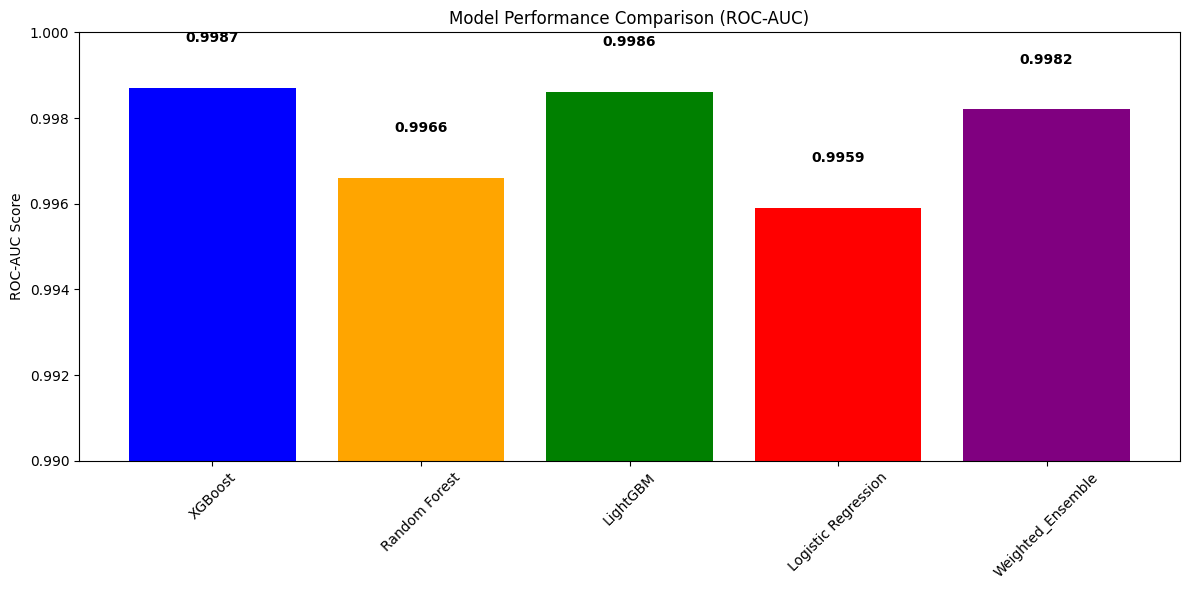

In [14]:
print("=" * 50)
print("PERFORMANCE SUMMARY")
print("=" * 50)

comparison_results = []

for model_name, result in tuning_results.items():
    cv_scores = result['cv_scores']

    comparison_results.append({
        'Model': model_name,
        'ROC-AUC': f"{np.mean(cv_scores['test_roc_auc']):.4f}",
        'Accuracy': f"{np.mean(cv_scores['test_accuracy']):.4f}",
        'F1-Score': f"{np.mean(cv_scores['test_f1']):.4f}",
        'Time (s)': f"{result['training_time']:.1f}"
    })

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.to_string(index=False))
print()

plt.figure(figsize=(12, 6))
models = comparison_df['Model']
roc_auc_scores = [float(x) for x in comparison_df['ROC-AUC']]

colors = []
for model in models:
    if 'Ensemble' in model:
        colors.append('purple')
    elif model == 'LightGBM':
        colors.append('green')
    elif model == 'XGBoost':
        colors.append('blue')
    elif model == 'Random Forest':
        colors.append('orange')
    else:
        colors.append('red')

bars = plt.bar(models, roc_auc_scores, color=colors)
plt.title('Model Performance Comparison (ROC-AUC)')
plt.ylabel('ROC-AUC Score')
plt.xticks(rotation=45)
plt.ylim(0.99, 1.0)

for bar, score in zip(bars, roc_auc_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(config.reports_dir / 'performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

CREATING ENHANCED VISUALIZATIONS


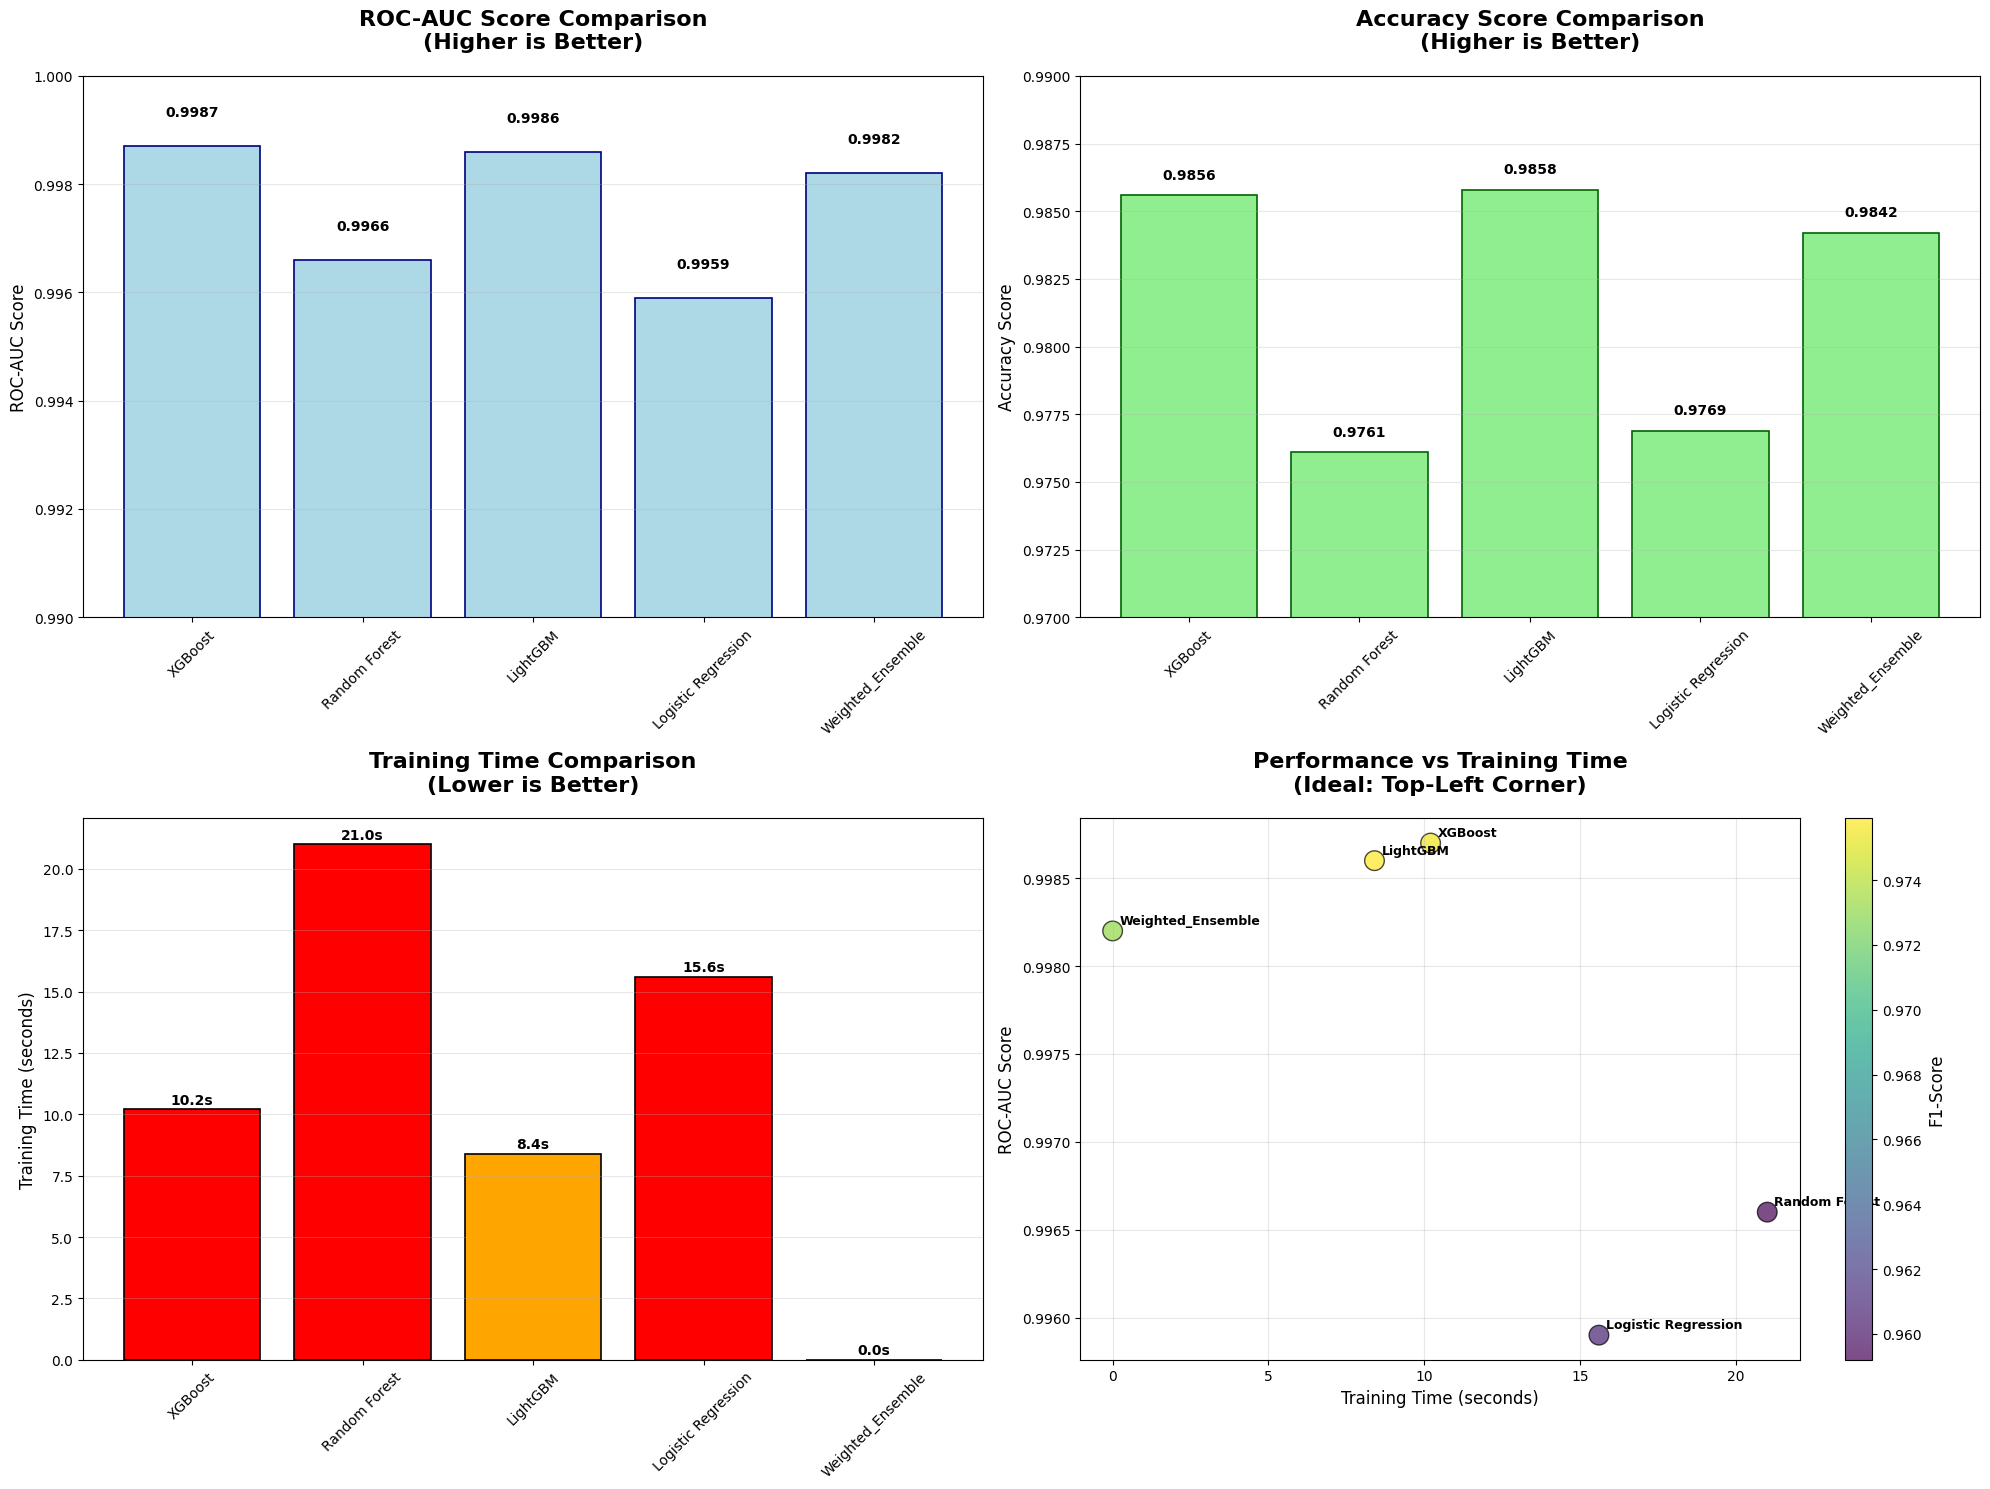

CREATING RADAR CHART...


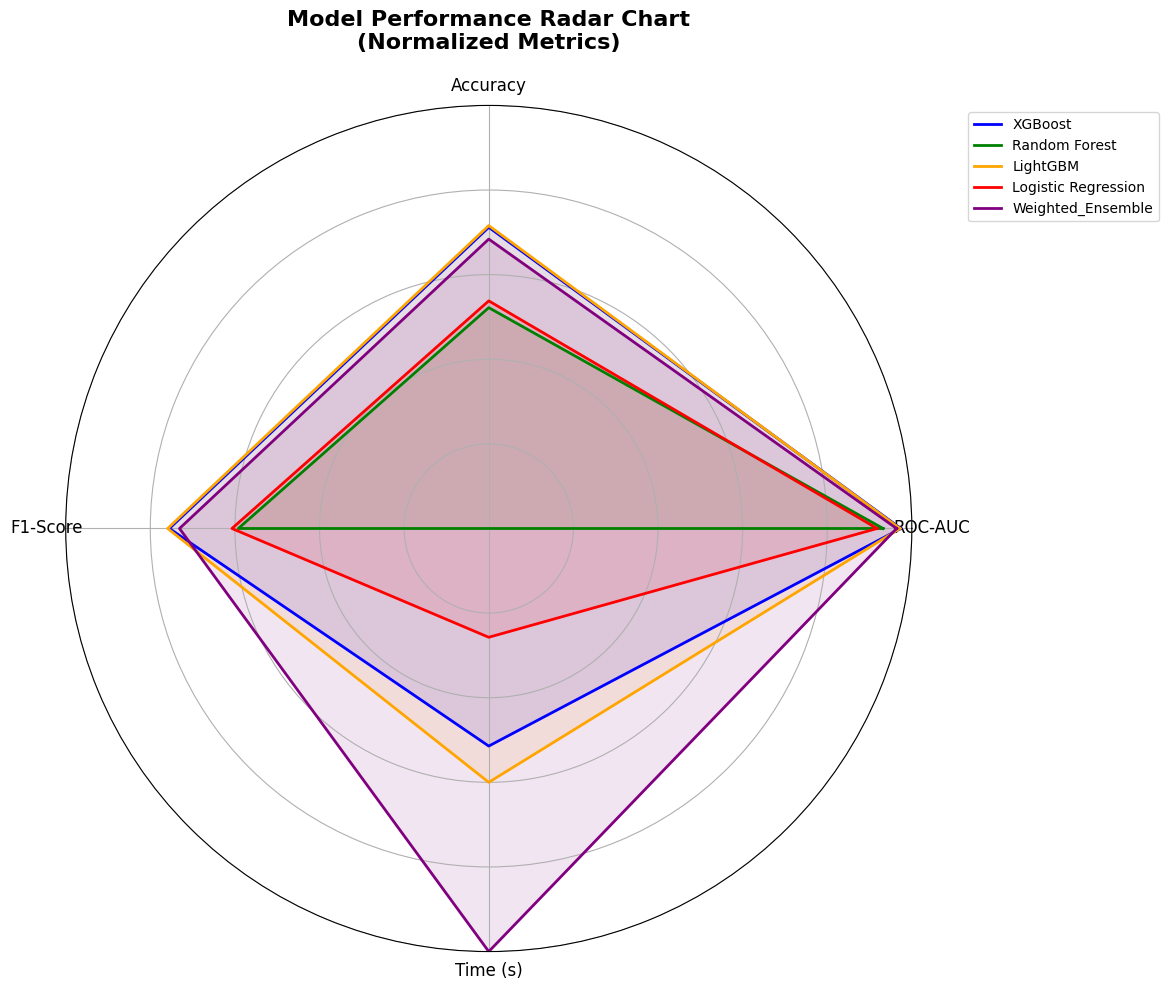

CREATING BEST MODEL PERFORMANCE BREAKDOWN...


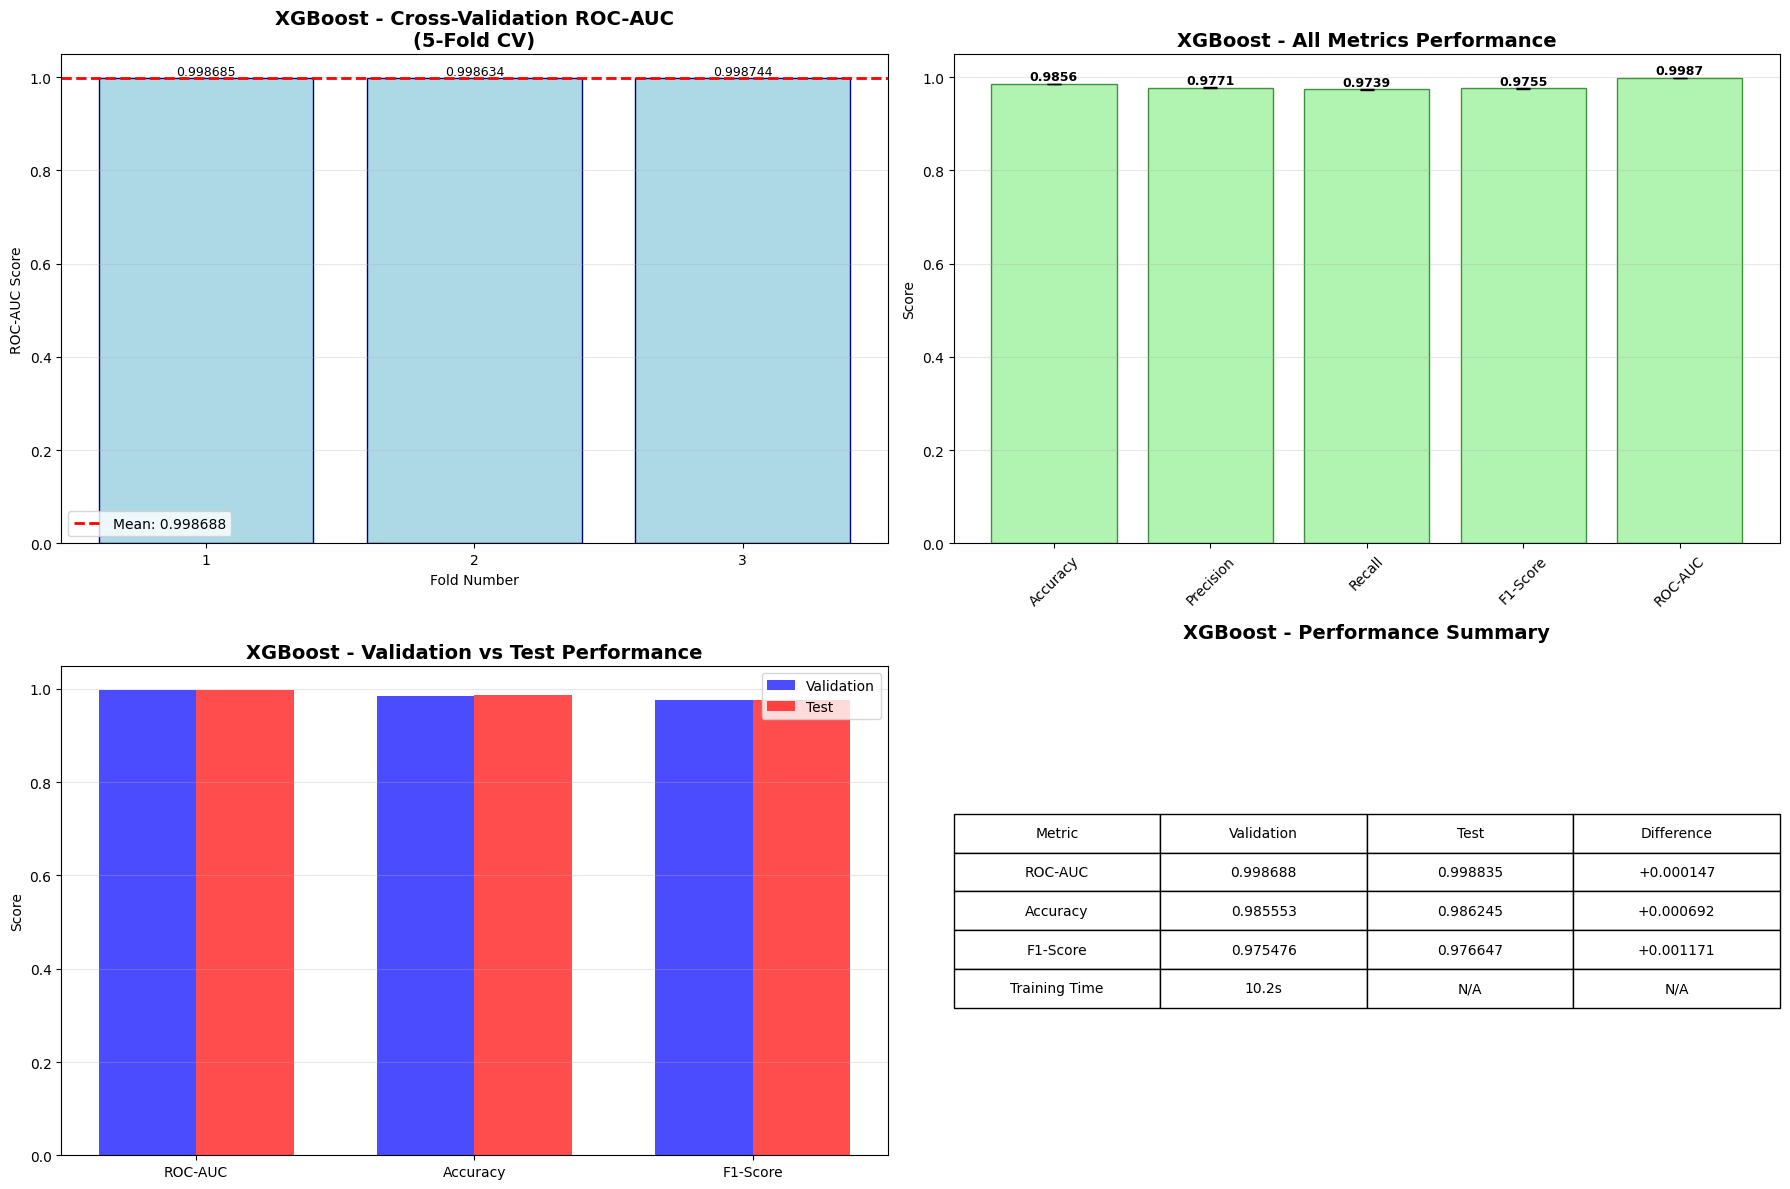

In [16]:
print("=" * 50)
print("CREATING ENHANCED VISUALIZATIONS")
print("=" * 50)

plt.style.use('default')
sns.set_palette("husl")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 15))

# Figure 1: ROC-AUC Comparison
models = comparison_df['Model']
roc_auc_values = [float(x) for x in comparison_df['ROC-AUC']]
accuracy_values = [float(x) for x in comparison_df['Accuracy']]

bars1 = ax1.bar(models, roc_auc_values, color='lightblue', edgecolor='navy', linewidth=1.2)
ax1.set_title('ROC-AUC Score Comparison\n(Higher is Better)', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('ROC-AUC Score', fontsize=12)
ax1.set_ylim(0.99, 1.0)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

for bar, value in zip(bars1, roc_auc_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{value:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Figure 2: Accuracy Comparison
bars2 = ax2.bar(models, accuracy_values, color='lightgreen', edgecolor='darkgreen', linewidth=1.2)
ax2.set_title('Accuracy Score Comparison\n(Higher is Better)', fontsize=16, fontweight='bold', pad=20)
ax2.set_ylabel('Accuracy Score', fontsize=12)
ax2.set_ylim(0.97, 0.99)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

for bar, value in zip(bars2, accuracy_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{value:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Figure 3: Training Time Comparison
training_times = [float(x) for x in comparison_df['Time (s)']]
colors_time = ['red' if time > 10 else 'orange' if time > 5 else 'green' for time in training_times]

bars3 = ax3.bar(models, training_times, color=colors_time, edgecolor='black', linewidth=1.2)
ax3.set_title('Training Time Comparison\n(Lower is Better)', fontsize=16, fontweight='bold', pad=20)
ax3.set_ylabel('Training Time (seconds)', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

for bar, time_val in zip(bars3, training_times):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{time_val:.1f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Figure 4: Performance vs Time Scatter Plot
f1_scores = [float(x) for x in comparison_df['F1-Score']]

scatter = ax4.scatter(training_times, roc_auc_values, s=200, c=f1_scores, cmap='viridis', alpha=0.7, edgecolors='black')
ax4.set_title('Performance vs Training Time\n(Ideal: Top-Left Corner)', fontsize=16, fontweight='bold', pad=20)
ax4.set_xlabel('Training Time (seconds)', fontsize=12)
ax4.set_ylabel('ROC-AUC Score', fontsize=12)
ax4.grid(True, alpha=0.3)

# Add model labels to scatter points
for i, model in enumerate(models):
    ax4.annotate(model, (training_times[i], roc_auc_values[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

# Add colorbar for F1-Score
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('F1-Score', fontsize=12)

plt.tight_layout()
plt.savefig(config.reports_dir / 'comprehensive_performance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("CREATING RADAR CHART...")

from math import pi

fig = plt.figure(figsize=(15, 10))

# Normalize metrics for radar chart (0-1 scale)
metrics_to_plot = ['ROC-AUC', 'Accuracy', 'F1-Score', 'Time (s)']
normalized_data = []

for _, row in comparison_df.iterrows():
    model_data = {}
    for metric in metrics_to_plot:
        if metric == 'Time (s)':
            # For time, lower is better - invert the scale
            time_val = float(row[metric])
            normalized_time = 1.0 - min(time_val / max(training_times), 1.0)
            model_data[metric] = normalized_time
        else:
            # For performance metrics, higher is better
            val = float(row[metric])
            min_val = 0.95 if metric in ['ROC-AUC', 'Accuracy'] else 0.9
            max_val = 1.0
            normalized_val = (val - min_val) / (max_val - min_val)
            model_data[metric] = normalized_val
    normalized_data.append(model_data)

# Create radar chart
ax = fig.add_subplot(111, polar=True)

# Set angles for each metric
angles = [n / float(len(metrics_to_plot)) * 2 * pi for n in range(len(metrics_to_plot))]
angles += angles[:1]  # Complete the circle

# Plot each model
colors = ['blue', 'green', 'orange', 'red', 'purple']
for i, (model, color) in enumerate(zip(models, colors)):
    values = [normalized_data[i][metric] for metric in metrics_to_plot]
    values += values[:1]  # Complete the circle

    ax.plot(angles, values, color=color, linewidth=2, label=model)
    ax.fill(angles, values, color=color, alpha=0.1)

# Add labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_to_plot, fontsize=12)
ax.set_yticklabels([])
ax.set_ylim(0, 1)

# Add legend
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=10)
plt.title('Model Performance Radar Chart\n(Normalized Metrics)', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(config.reports_dir / 'performance_radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("CREATING BEST MODEL PERFORMANCE BREAKDOWN...")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

# Get best model results
best_model_results = tuning_results[best_model_name]
cv_scores = best_model_results['cv_scores']

# Plot 1: Cross-validation ROC-AUC scores
cv_fold_scores = cv_scores['test_roc_auc']
fold_numbers = range(1, len(cv_fold_scores) + 1)

bars = ax1.bar(fold_numbers, cv_fold_scores, color='lightblue', edgecolor='navy')
ax1.axhline(y=np.mean(cv_fold_scores), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(cv_fold_scores):.6f}')
ax1.set_title(f'{best_model_name} - Cross-Validation ROC-AUC\n(5-Fold CV)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Fold Number')
ax1.set_ylabel('ROC-AUC Score')
ax1.set_xticks(fold_numbers)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

for bar, score in zip(bars, cv_fold_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
             f'{score:.6f}', ha='center', va='bottom', fontsize=9)

# Plot 2: All metrics comparison
metrics = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_roc_auc']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metric_values = [np.mean(cv_scores[metric]) for metric in metrics]
metric_stds = [np.std(cv_scores[metric]) for metric in metrics]

bars = ax2.bar(metric_names, metric_values, yerr=metric_stds, capsize=5,
               color='lightgreen', edgecolor='darkgreen', alpha=0.7)
ax2.set_title(f'{best_model_name} - All Metrics Performance', fontsize=14, fontweight='bold')
ax2.set_ylabel('Score')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, metric_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{value:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: Validation vs Test Performance
comparison_metrics = ['ROC-AUC', 'Accuracy', 'F1-Score']
validation_scores = [best_model_details['roc_auc'], best_model_details['accuracy'], best_model_details['f1']]
test_scores = [test_metrics['roc_auc'], test_metrics['accuracy'], test_metrics['f1']]

x_pos = np.arange(len(comparison_metrics))
width = 0.35

bars1 = ax3.bar(x_pos - width/2, validation_scores, width, label='Validation', color='blue', alpha=0.7)
bars2 = ax3.bar(x_pos + width/2, test_scores, width, label='Test', color='red', alpha=0.7)

ax3.set_title(f'{best_model_name} - Validation vs Test Performance', fontsize=14, fontweight='bold')
ax3.set_ylabel('Score')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(comparison_metrics)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Performance Summary Table
ax4.axis('off')
summary_data = [
    ['Metric', 'Validation', 'Test', 'Difference'],
    ['ROC-AUC', f"{best_model_details['roc_auc']:.6f}", f"{test_metrics['roc_auc']:.6f}",
     f"{test_metrics['roc_auc'] - best_model_details['roc_auc']:+.6f}"],
    ['Accuracy', f"{best_model_details['accuracy']:.6f}", f"{test_metrics['accuracy']:.6f}",
     f"{test_metrics['accuracy'] - best_model_details['accuracy']:+.6f}"],
    ['F1-Score', f"{best_model_details['f1']:.6f}", f"{test_metrics['f1']:.6f}",
     f"{test_metrics['f1'] - best_model_details['f1']:+.6f}"],
    ['Training Time', f"{best_model_details['training_time']:.1f}s", 'N/A', 'N/A']
]

table = ax4.table(cellText=summary_data, loc='center', cellLoc='center',
                  colWidths=[0.25, 0.25, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

ax4.set_title(f'{best_model_name} - Performance Summary', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(config.reports_dir / 'best_model_performance_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
print("=" * 50)
print("FINAL MODEL SELECTION")
print("=" * 50)

best_model_name = None
best_roc_auc = 0
best_model_details = {}

for model_name, result in tuning_results.items():
    cv_scores = result['cv_scores']
    roc_auc = np.mean(cv_scores['test_roc_auc'])

    if roc_auc > best_roc_auc:
        best_roc_auc = roc_auc
        best_model_name = model_name
        best_model_details = {
            'roc_auc': roc_auc,
            'accuracy': np.mean(cv_scores['test_accuracy']),
            'f1': np.mean(cv_scores['test_f1']),
            'training_time': result['training_time']
        }

best_model = tuning_results[best_model_name]['model']

print(f"BEST MODEL: {best_model_name}")
print("-" * 30)
print(f"Validation ROC-AUC: {best_model_details['roc_auc']:.6f}")
print(f"Validation Accuracy: {best_model_details['accuracy']:.6f}")
print(f"Validation F1-Score: {best_model_details['f1']:.6f}")
print(f"Training Time: {best_model_details['training_time']:.1f}s")
print()

print("TEST SET EVALUATION:")
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

test_metrics = {
    'roc_auc': roc_auc_score(y_test, y_pred_proba),
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred)
}

print(f"Test ROC-AUC:  {test_metrics['roc_auc']:.6f}")
print(f"Test Accuracy: {test_metrics['accuracy']:.6f}")
print(f"Test F1-Score: {test_metrics['f1']:.6f}")
print()

print("PERFORMANCE COMPARISON:")
print(f"{'Metric':<12} {'Validation':<12} {'Test':<12} {'Diff':<10}")
print("-" * 50)
for metric in ['roc_auc', 'accuracy', 'f1']:
    val_score = best_model_details[metric]
    test_score = test_metrics[metric]
    diff = test_score - val_score
    diff_color = "✓" if abs(diff) < 0.01 else "⚠" if abs(diff) < 0.05 else "✗"
    print(f"{metric.upper():<12} {val_score:<12.6f} {test_score:<12.6f} {diff:+.6f} {diff_color}")

FINAL MODEL SELECTION
BEST MODEL: XGBoost
------------------------------
Validation ROC-AUC: 0.998688
Validation Accuracy: 0.985553
Validation F1-Score: 0.975476
Training Time: 10.2s

TEST SET EVALUATION:
Test ROC-AUC:  0.998835
Test Accuracy: 0.986245
Test F1-Score: 0.976647

PERFORMANCE COMPARISON:
Metric       Validation   Test         Diff      
--------------------------------------------------
ROC_AUC      0.998688     0.998835     +0.000147 ✓
ACCURACY     0.985553     0.986245     +0.000692 ✓
F1           0.975476     0.976647     +0.001171 ✓


In [17]:
print("=" * 50)
print("SAVING RESULTS")
print("=" * 50)

tuning_output = {
    'best_model': {
        'name': best_model_name,
        'model': best_model,
        'validation_performance': best_model_details,
        'test_performance': test_metrics
    },
    'all_models': {
        model_name: {
            'model': result['model'],
            'performance': {
                'roc_auc': np.mean(result['cv_scores']['test_roc_auc']),
                'accuracy': np.mean(result['cv_scores']['test_accuracy']),
                'f1': np.mean(result['cv_scores']['test_f1'])
            }
        }
        for model_name, result in tuning_results.items()
    },
    'comparison_results': comparison_results
}

joblib.dump(tuning_output, config.models_dir / 'final_tuned_models.pkl')
comparison_df.to_csv(config.reports_dir / 'model_comparison.csv', index=False)

print("RESULTS SAVED:")
print(f"- Models: {config.models_dir / 'final_tuned_models.pkl'}")
print(f"- Comparison: {config.reports_dir / 'model_comparison.csv'}")
print(f"- Plot: {config.reports_dir / 'performance_comparison.png'}")
print()

print("FINAL SUMMARY:")
print(f"Best Model: {best_model_name}")
print(f"Test ROC-AUC: {test_metrics['roc_auc']:.6f}")
print(f"Models Compared: {len(comparison_results)}")
print()

print("OPTIMIZATION COMPLETED SUCCESSFULLY!")

SAVING RESULTS
RESULTS SAVED:
- Models: C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\AIDS NOTES\MindScope\results\models\final_tuned_models.pkl
- Comparison: C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\AIDS NOTES\MindScope\results\reports\model_comparison.csv
- Plot: C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\AIDS NOTES\MindScope\results\reports\performance_comparison.png

FINAL SUMMARY:
Best Model: XGBoost
Test ROC-AUC: 0.998835
Models Compared: 5

OPTIMIZATION COMPLETED SUCCESSFULLY!
